# Example of safe absorbing states

#### Control Synthesis from Linear Temporal Logic Specifications using Model-Free Reinforcement Learning

Page 6, the first example

In [1]:
%matplotlib inline
from mdp import GridMDP
from oa import OmegaAutomaton
from controlsyn import ControlSynthesis
import numpy as np 
from IPython.display import display, Image

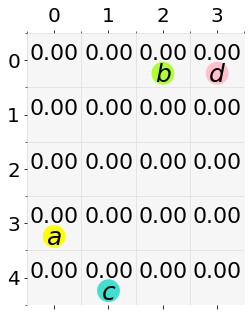

In [2]:

# MDP Description
shape = (5,4)
# E: Empty, T: Trap, B: Obstacle
structure = np.array([
['E',  'E',  'E',  'E'],
['E',  'E',  'E',  'E'],
['E',  'E',  'E',  'E'],
['E',  'E',  'E',  'E'],
['E',  'E',  'E',  'E']
])

# Labels of the states
label = np.array([
[(),    (),    ('b',),('d',)],
[(),    (),    (),    ()],
[(),    (),    (),    ()],
[('a',),(),    (),    ()],
[(),    ('c',),(),    ()]
],dtype=object)
# Colors of the labels
lcmap={
    ('a',):'yellow',
    ('b',):'greenyellow',
    ('c',):'turquoise',
    ('d',):'pink'
}
grid_mdp = GridMDP(shape=shape,structure=structure,label=label,lcmap=lcmap,figsize=5)  # Use figsize=4 for smaller figures
grid_mdp.plot()

In [3]:
# properties of grid_mdp

print(grid_mdp.shape)        # size of MDP
print(grid_mdp.random_state())  # generate a state randomly

#actions
print(grid_mdp.A)

# trainsition matrix
for state in grid_mdp.states():
    for action, action_name in enumerate(grid_mdp.A):
        print(state, action, action_name, grid_mdp.transition_probs[state][action])

# rewards doesn't assigned (then zeros)
print(grid_mdp.reward)

# labels are given
print(grid_mdp.label)

(5, 4)
(4, 0)
['U', 'D', 'R', 'L']
(0, 0) 0 U ([(0, 1), (0, 0)], [0.09999999999999998, 0.9])
(0, 0) 1 D ([(1, 0), (0, 1), (0, 0)], [0.8, 0.09999999999999998, 0.09999999999999998])
(0, 0) 2 R ([(1, 0), (0, 1), (0, 0)], [0.09999999999999998, 0.8, 0.09999999999999998])
(0, 0) 3 L ([(1, 0), (0, 0)], [0.09999999999999998, 0.9])
(0, 1) 0 U ([(0, 0), (0, 2), (0, 1)], [0.09999999999999998, 0.09999999999999998, 0.8])
(0, 1) 1 D ([(1, 1), (0, 0), (0, 2)], [0.8, 0.09999999999999998, 0.09999999999999998])
(0, 1) 2 R ([(1, 1), (0, 2), (0, 1)], [0.09999999999999998, 0.8, 0.09999999999999998])
(0, 1) 3 L ([(1, 1), (0, 0), (0, 1)], [0.09999999999999998, 0.8, 0.09999999999999998])
(0, 2) 0 U ([(0, 1), (0, 3), (0, 2)], [0.09999999999999998, 0.09999999999999998, 0.8])
(0, 2) 1 D ([(1, 2), (0, 1), (0, 3)], [0.8, 0.09999999999999998, 0.09999999999999998])
(0, 2) 2 R ([(1, 2), (0, 3), (0, 2)], [0.09999999999999998, 0.8, 0.09999999999999998])
(0, 2) 3 L ([(1, 2), (0, 1), (0, 2)], [0.09999999999999998, 0.8, 0

In [4]:
# LTL Specification
ltl = ('G ('
    '(!d) & '
    '((b & (!(X b)))->(X ((!b) U (a|c)))) & '
    '(((!b) & (X b) & (!(X X b)))->((!a) U c)) & '
    '(a->(X ((!a) U b))) & '
    '(c->((!a) U b)) & '
    '((b & (X b))->(F a))'
')')

# Translate the LTL formula to an LDBA
oa = OmegaAutomaton(ltl)
print('Number of Omega-automaton states (including the trap state):',oa.shape[1])
display(oa)


Number of Omega-automaton states (including the trap state): 57


In [5]:

print('Transition function: ['),print(*['  '+str(t) for t in oa.delta],sep=',\n'),print(']')
# 0-()->0; 0-a->0; 0-b->0; 0-c->3; 0-a,b->0, 0-a,c->3, 0-b,c->3, 0-a,b,c->3
# 1-()->3; 1-a->3;...

print('Epsilon transition: ['),print(*['  '+str(t) for t in oa.eps],sep=',\n'),print(']')
# 0-eps->1; 0-eps->2; no for states 1, 2, 3


Transition function: [
  {(): 35, ('a',): 23, ('b',): 10, ('c',): 30, ('d',): 56, ('a', 'b'): 9, ('a', 'c'): 56, ('a', 'd'): 56, ('b', 'c'): 10, ('b', 'd'): 56, ('c', 'd'): 56, ('a', 'b', 'c'): 9, ('a', 'b', 'd'): 56, ('a', 'c', 'd'): 56, ('b', 'c', 'd'): 56, ('a', 'b', 'c', 'd'): 56},
  {(): 2, ('a',): 56, ('b',): 3, ('c',): 1, ('d',): 56, ('a', 'b'): 4, ('a', 'c'): 56, ('a', 'd'): 56, ('b', 'c'): 3, ('b', 'd'): 56, ('c', 'd'): 56, ('a', 'b', 'c'): 4, ('a', 'b', 'd'): 56, ('a', 'c', 'd'): 56, ('b', 'c', 'd'): 56, ('a', 'b', 'c', 'd'): 56},
  {(): 2, ('a',): 56, ('b',): 41, ('c',): 1, ('d',): 56, ('a', 'b'): 22, ('a', 'c'): 56, ('a', 'd'): 56, ('b', 'c'): 3, ('b', 'd'): 56, ('c', 'd'): 56, ('a', 'b', 'c'): 4, ('a', 'b', 'd'): 56, ('a', 'c', 'd'): 56, ('b', 'c', 'd'): 56, ('a', 'b', 'c', 'd'): 56},
  {(): 31, ('a',): 18, ('b',): 3, ('c',): 19, ('d',): 56, ('a', 'b'): 9, ('a', 'c'): 56, ('a', 'd'): 56, ('b', 'c'): 3, ('b', 'd'): 56, ('c', 'd'): 56, ('a', 'b', 'c'): 9, ('a', 'b', 'd'): 56

(None, None, None)

In [6]:
# Construct the product MDP
csrl = ControlSynthesis(grid_mdp,oa)

In [7]:
print(oa.shape)     # oa.shape[1] is the number of states
print(grid_mdp.shape)
print(csrl.shape)
print(csrl.shape[:-1])  # this is size of states in product MDP (1,4,5,4)
#(,8) supposes to be the number of actions  (len(grid_mdp.A)+oa.shape[1])
print(grid_mdp.A)
print(oa.shape[1])

(1, 57)
(5, 4)
(1, 57, 5, 4, 61)
(1, 57, 5, 4)
['U', 'D', 'R', 'L']
57


In [8]:
# In product MDP, states are represented by [i,q,r,c] where q is the number of states in the automaton,
# [r, c] represents the states of MDP, i.e., # of rows, # of columns
# i is the number of MDPs. (for multi-agent?)

for i,q,r,c in csrl.states():
    None
    #print(i, q, r, c)      # if printed (need to comment "None"), i=0, q=0->3, r=0->4, c=0->3     

In [9]:
print(csrl.A.shape) # automaton size (1,4) x MDP size (5,4)
# every element of csrl.A[i,q,r,c] is a list of possible actions

# examples,

print(csrl.A[0,0,0,0]) # the first 0 represent the first agent (i.e., the first MDP) 
#the second 0 represents q0, the last two 0s represent MDP state (0,0). 
# the list of possible actions in this product MDP state has [0,1,2,3] for "U D R L" and [5,6] for epsilon (to q1 and q2)

print(csrl.A[0,1,0,0]) 
# q1 (the second 1) doesn't have epsilon actions so the list of possible actions only has ["U D R L"]

(1, 57, 5, 4)
[0, 1, 2, 3]
[0, 1, 2, 3]


In [10]:
# transition probability

for action in csrl.A[0,0,0,0]:
    print(csrl.transition_probs[0,0,0,0][action])
 


([(0, 35, 0, 1), (0, 35, 0, 0)], [0.09999999999999998, 0.9])
([(0, 35, 1, 0), (0, 35, 0, 1), (0, 35, 0, 0)], [0.8, 0.09999999999999998, 0.09999999999999998])
([(0, 35, 1, 0), (0, 35, 0, 1), (0, 35, 0, 0)], [0.09999999999999998, 0.8, 0.09999999999999998])
([(0, 35, 1, 0), (0, 35, 0, 0)], [0.09999999999999998, 0.9])


In [11]:
# rewards, print non-zero reward and the corresponding product MDP states. Other rewards are zeros. 
# the rewards are based on LDBA accepting sets, and the label of MDP state

print('(transition-based) Acceptance: ['),print(*['  '+str(t) for t in oa.acc],sep=',\n'),print(']')

for i,q,r,c in csrl.states():
    if csrl.reward[i, q, r, c] > 1.e-9:
        print((i,q,r, c), csrl.reward[i, q, r, c])


        
# ignore the first digit 0, because it is only one agent
# the second digit 1 means q1 in LDBA, 2 means q2 in LDBA
# at q1, (1,3) and (3,0) are labeled with ('b',)
# at q2, (1,2) and (3,1) are labeled with ('a',) 

print('generating a random state', csrl.random_state())
# it just generates a randome state of product MDP. 
# It is not the initial random state, which shall be (0, 0, *, *)

(transition-based) Acceptance: [
  {(): [None], ('a',): [None], ('b',): [None], ('c',): [None], ('d',): [None], ('a', 'b'): [None], ('a', 'c'): [None], ('a', 'd'): [None], ('b', 'c'): [None], ('b', 'd'): [None], ('c', 'd'): [None], ('a', 'b', 'c'): [None], ('a', 'b', 'd'): [None], ('a', 'c', 'd'): [None], ('b', 'c', 'd'): [None], ('a', 'b', 'c', 'd'): [None]},
  {(): [None], ('a',): [None], ('b',): [True], ('c',): [None], ('d',): [None], ('a', 'b'): [None], ('a', 'c'): [None], ('a', 'd'): [None], ('b', 'c'): [True], ('b', 'd'): [None], ('c', 'd'): [None], ('a', 'b', 'c'): [None], ('a', 'b', 'd'): [None], ('a', 'c', 'd'): [None], ('b', 'c', 'd'): [None], ('a', 'b', 'c', 'd'): [None]},
  {(): [None], ('a',): [None], ('b',): [True], ('c',): [None], ('d',): [None], ('a', 'b'): [None], ('a', 'c'): [None], ('a', 'd'): [None], ('b', 'c'): [True], ('b', 'd'): [None], ('c', 'd'): [None], ('a', 'b', 'c'): [None], ('a', 'b', 'd'): [None], ('a', 'c', 'd'): [None], ('b', 'c', 'd'): [None], ('a', 'b

In [18]:
Q=csrl.q_learning(start=(4,1),T=1000,K=30000)  # it seems that K=30000 is not enough  
# the original code uses T=1000,K=100000

0
5000
10000
15000
20000
25000
30000


In [19]:
value=np.max(Q,axis=4)
print(Q.shape)
print(value.shape)

(1, 57, 5, 4, 61)
(1, 57, 5, 4)


In [21]:
csrl.plot(value)
# q=2, cb
# q=41, bc
# q=12, ba

interactive(children=(IntSlider(value=0, description='i', max=0), IntSlider(value=0, description='q', max=56),…

In [23]:
policy=np.argmax(Q,axis=4)
csrl.plot(value,policy)

interactive(children=(IntSlider(value=0, description='i', max=0), IntSlider(value=0, description='q', max=56),…

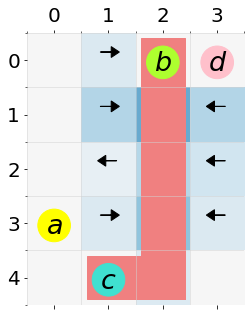

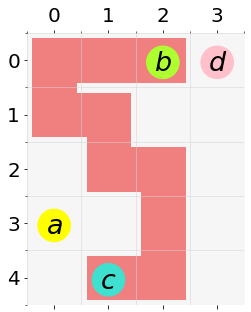

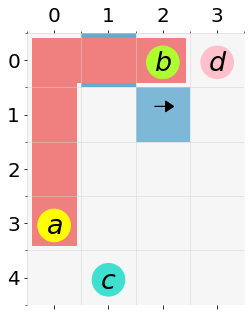

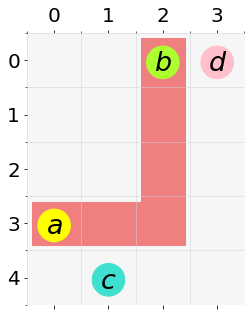

In [24]:
# Plot the important parts of the policy

policy=np.argmax(Q,axis=4)

hidden = [(0,0),(1,0),(2,0),(3,0),(4,0),(4,1),(0,2),(0,3)]
path = {
    (4,1) : 'r',
    (4,2) : 'lu',
    (3,2) : 'du',
    (2,2) : 'du',
    (1,2) : 'du',
    (0,2) : 'd'
}
csrl.plot(value,policy,iq=(0,2),save='nursery_scenario_policy_cb.pdf',path=path,hidden=hidden)


hidden = [(3,0),(4,0),(4,1),(0,2),(0,3)]
path = {
    (0,2) : 'l',
    (0,1) : 'lr',
    (0,0) : 'rd',
    (1,0) : 'ur',
    (1,1) : 'ld',
    (2,1) : 'ur',
    (2,2) : 'ld',
    (3,2) : 'ud',
    (4,2) : 'ul',
    (4,1) : 'r'
}
csrl.plot(value,policy,iq=(0,41),save='nursery_scenario_policy_bc.pdf',hidden=hidden,path=path)

hidden=[(3,0),(4,0),(4,1),(4,2),(4,3),(0,2),(0,3)]
path = {
    (0,2) : 'l',
    (0,1) : 'lr',
    (0,0) : 'rd',
    (1,0) : 'ud',
    (2,0) : 'ud',
    (3,0) : 'u'
}
csrl.plot(value,policy,iq=(0,12),save='nursery_scenario_policy_ba.pdf',hidden=hidden,path=path)

hidden=[(3,0),(4,0),(0,2),(0,3),(4,1)]
path = {
    (3,0) : 'r',
    (3,1) : 'lr',
    (3,2) : 'lu',
    (2,2) : 'du',
    (1,2) : 'du',
    (0,2) : 'd'
}
csrl.plot(value,policy,iq=(0,9),save='nursery_scenario_policy_ab.pdf',hidden=hidden,path=path)

In [17]:
episode=csrl.simulate(value, policy,start=(4,1),T=300, animation = True)

# if set animation=True, "safeAbsorbingStates.mp4" will be generated.
# However, you need to create an "animation" folder before running this code. 
# The "animation" folder will save the .png files, which are then used to generate the movie in the current folder.

interactive(children=(IntSlider(value=0, description='t', max=299), Output()), _dom_classes=('widget-interact'…